In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install datasets transformers evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 8.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.5.1
    Uninstalling fsspec-2025.5.1:
      Successfully uninstalled fsspec-2025.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidi

In [2]:
#data download and preprocessing

from datasets import load_dataset
from datasets import concatenate_datasets
from transformers import AutoTokenizer
from pympler import asizeof
from torch.utils.data import DataLoader
from collections import Counter

# Load datasets
mnli_dataset = load_dataset("glue", "mnli")
snli_dataset = load_dataset("snli")

# Remove 'idx' column from MNLI
mnli_dataset = {
    split: ds.remove_columns("idx") 
    for split, ds in mnli_dataset.items()
}

# Function to filter out invalid labels
def filter_valid(example):
    return example["label"] != -1

# Filter all SNLI splits
snli_dataset = {
    split: ds.filter(filter_valid)
    for split, ds in snli_dataset.items()
}

# Filter all MNLI splits except test split
mnli_dataset = {
    split: ds.filter(filter_valid) if "test" not in split else ds
    for split, ds in mnli_dataset.items()
}


train_dataset = concatenate_datasets([
    snli_dataset['train'], 
    mnli_dataset['train']
]).shuffle(seed=42)


validation_dataset = concatenate_datasets([
    snli_dataset['validation'], 
    mnli_dataset['validation_matched']
]).shuffle(seed=42)


validation_mismatched_dataset = mnli_dataset['validation_mismatched']


# Check the dataset structure
print(mnli_dataset)
print(snli_dataset)
# print(mnli_dataset["train"][0])  # Look at an example
# print(snli_dataset["train"][0])  # Look at an example

#snli all -1
# print(snli_dataset["test"][0])
# print(mnli_dataset["test_matched"][0])
# print(mnli_dataset["test_mismatched"][0])


# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")


# tokenize_function with dynamic padding
def tokenize_function(example):
    return tokenizer(
        example["premise"],
        example["hypothesis"],
        padding=False,  # No padding during tokenization
        truncation=True,
        max_length=128
    )

# Tokenize each dataset separately
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_validation = validation_dataset.map(tokenize_function, batched=True)
tokenized_validation_mismatched = validation_mismatched_dataset.map(tokenize_function, batched=True)

# Tokenize test sets (if needed for evaluation)
tokenized_test_mnli_matched = mnli_dataset["test_matched"].map(tokenize_function, batched=True)
tokenized_test_mnli_mismatched = mnli_dataset["test_mismatched"].map(tokenize_function, batched=True)
tokenized_test_snli = snli_dataset["test"].map(tokenize_function, batched=True)


# Change dataset format to use "labels" instead of "label"
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_validation = tokenized_validation.rename_column("label", "labels")
tokenized_validation_mismatched = tokenized_validation_mismatched.rename_column("label", "labels")

tokenized_test_mnli_matched = tokenized_test_mnli_matched.rename_column("label", "labels")
tokenized_test_mnli_mismatched = tokenized_test_mnli_mismatched.rename_column("label", "labels")
tokenized_test_snli = tokenized_test_snli.rename_column("label", "labels")

# Set format for PyTorch
# train and validation split
tokenized_train.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_validation.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_validation_mismatched.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
# test split
tokenized_test_mnli_matched.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_test_mnli_mismatched.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_test_snli.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])



print(f"Train dataset size: {len(tokenized_train)}")
print(f"Validation dataset size: {len(tokenized_validation)}")
print(f"Validation mismatched size: {len(tokenized_validation_mismatched)}")

# attention_mask check 
print(tokenized_train[0]["attention_mask"])  # Expected: [1, 1, ..., 1, 0, ..., 0]

# Check the train dataset dtype and size
size_in_bytes = asizeof.asizeof(tokenized_train)
size_in_mb = size_in_bytes / (1024 * 1024)
print(f"Total size of tokenized_train: {size_in_mb:.2f} MB")

# Check label distribution-count of each sets 0,1,2
train_labels = tokenized_train["labels"].tolist()
print(f"Label distribution in train: {Counter(train_labels)}")

print(tokenized_train[0]["input_ids"].shape, tokenized_train[0]["input_ids"].dtype)
print(tokenized_train[0]["token_type_ids"].shape, tokenized_train[0]["token_type_ids"].dtype)
print(tokenized_train[0]["attention_mask"].shape, tokenized_train[0]["attention_mask"].dtype)
print(tokenized_train[0]["labels"].shape, tokenized_train[0]["labels"].dtype)


# Check data types of each column
sample = tokenized_train[0]  # Get the first example
for key, value in sample.items():
    print(f"Column: {key}, Data Type: {value.dtype}")

README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/52.2M [00:00<?, ?B/s]

(…)alidation_matched-00000-of-00001.parquet:   0%|          | 0.00/1.21M [00:00<?, ?B/s]

(…)dation_mismatched-00000-of-00001.parquet:   0%|          | 0.00/1.25M [00:00<?, ?B/s]

test_matched-00000-of-00001.parquet:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

...

Map:   0%|          | 0/9832 [00:00<?, ? examples/s]

Map:   0%|          | 0/9796 [00:00<?, ? examples/s]

Map:   0%|          | 0/9847 [00:00<?, ? examples/s]

Map:   0%|          | 0/9824 [00:00<?, ? examples/s]

Train dataset size: 942069
Validation dataset size: 19657
Validation mismatched size: 9832
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
Total size of tokenized_train: 629.80 MB
Label distribution in train: Counter({0: 314315, 2: 314090, 1: 313664})
torch.Size([13]) torch.int64
torch.Size([13]) torch.int64
torch.Size([13]) torch.int64
torch.Size([]) torch.int64
Column: labels, Data Type: torch.int64
Column: input_ids, Data Type: torch.int64
Column: token_type_ids, Data Type: torch.int64
Column: attention_mask, Data Type: torch.int64


In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import time
import wandb
import random
import os
import inspect
from tqdm import tqdm
from contextlib import nullcontext
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint



# ------------------------------------dynamic tanh---------------------------------------------------
class DyT(nn.Module):
    def __init__(self, num_features, alpha_init_value=0.5):
        super().__init__()
        self.alpha = nn.Parameter(torch.ones(1) * alpha_init_value)
        self.weight = nn.Parameter(torch.ones(num_features))
        self.bias = nn.Parameter(torch.zeros(num_features))
    
    def forward(self, x):
        x = torch.tanh(self.alpha * x)
        return x * self.weight + self.bias

# ------------------------------------MHA---------------------------------------------------

class Attention(nn.Module):
    """Multi-head attention"""
    def __init__(self, config):
        super().__init__()
        assert config.n_embed % config.n_head == 0, "Embedding dim must be divisible by num heads"

        self.n_head = config.n_head
        self.n_embed = config.n_embed
        self.head_dim = config.n_embed // config.n_head

        self.qkv_proj = nn.Linear(config.n_embed, 3 * config.n_embed)
        self.output_proj = nn.Linear(config.n_embed, config.n_embed)
        self.dropout = nn.Dropout(config.dropout)



    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor = None) -> torch.Tensor:
        B, T, C = x.shape

        # Project to queries, keys, values
        qkv = self.qkv_proj(x)
        q, k, v = qkv.split(self.n_embed, dim=2)

        # Reshape for multi-head attention
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)  # (B, nh, T, hs)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)  # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)  # (B, nh, T, hs)


        # Process attention mask
        attn_mask = None
        if attention_mask is not None:
            # Expand from (B, T) to (B, 1, 1, T) for broadcasting
            attn_mask = attention_mask.unsqueeze(1).unsqueeze(2)

        # Compute attention
        y = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=attn_mask,
            is_causal=False
        )

        # Reshape and project
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.dropout(self.output_proj(y))

        return y

# -----------------------------------Expert--------------------------------------------------

class Expert(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embed,2*config.n_embed),
            nn.GELU(),
            nn.Linear(2*config.n_embed,config.n_embed),
            nn.Dropout(config.dropout)
        )

    def forward(self,x):
        return self.net(x)

# ------------------------------------MLP--------------------------------------------------

class MLP(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embed,4*config.n_embed),
            nn.GELU(),
            nn.Linear(4*config.n_embed,config.n_embed),
            nn.Dropout(config.dropout)
        )

    def forward(self,x):
        return self.net(x)

# ------------------------------------NoisyTopkRouter--------------------------------------------------

class NoisyTopkRouter(nn.Module):
    def __init__(self, config):
        super(NoisyTopkRouter, self).__init__()
        self.top_k = config.top_k
        # Layer for router logits
        self.topkroute_linear = nn.Linear(config.n_embed, config.num_experts)
        self.noise_linear = nn.Linear(config.n_embed, config.num_experts)
    
    def forward(self, mh_output):
        # mh_ouput is the output tensor from multihead self attention block
        logits = self.topkroute_linear(mh_output)
        # Noise logits
        noise_logits = self.noise_linear(mh_output)
        # Adding scaled unit gaussian noise to the logits
        noise = torch.randn_like(logits) * F.softplus(noise_logits)
        noisy_logits = logits + noise
        top_k_logits, indices = noisy_logits.topk(self.top_k, dim=-1)
        zeros = torch.full_like(noisy_logits, float('-inf'))
        sparse_logits = zeros.scatter(-1, indices, top_k_logits)
        router_output = F.softmax(sparse_logits, dim=-1)
        return router_output, indices, logits


# ------------------------------------SparseMoE--------------------------------------------------

class SparseMoE(nn.Module):
    def __init__(self, config):
        super(SparseMoE, self).__init__()
        self.router = NoisyTopkRouter(config)
        self.experts = nn.ModuleList([Expert(config) for _ in range(config.num_experts)])
        self.top_k = config.top_k
        self.capacity_factor = config.capacity_factor
        self.num_experts = config.num_experts
        
        # Load balancing parameters
        self.use_load_balancing = getattr(config, "use_load_balancing", True)
        self.load_balance_weight = getattr(config, "load_balance_weight", 0.01)
        self.aux_loss = 0.0
    
    def _compute_load_balancing_loss(self, router_logits, expert_indices):
        """
        Computes auxiliary load balancing loss to encourage uniform expert utilization
        
        Args:
            router_logits: Original router logits before noise [batch_size, seq_len, num_experts]
            expert_indices: Expert assignments [batch_size, seq_len, top_k]
        """
        # Calculate fraction of tokens assigned to each expert
        batch_size, seq_len, _ = router_logits.shape
        
        # More efficient one-hot representation of expert assignment
        # Shape: [batch_size, seq_len, top_k, num_experts]
        one_hot = F.one_hot(expert_indices, num_classes=self.num_experts)
        # Sum across top-k dimension to get mask of shape [batch_size, seq_len, num_experts]
        mask = one_hot.sum(dim=2).float()
        
        # Calculate the fraction of tokens routed to each expert
        routing_probs = mask.mean(dim=[0, 1])  # Shape [num_experts]
        
        # Calculate router probabilities from logits
        router_probs = F.softmax(router_logits, dim=-1)  # [batch_size, seq_len, num_experts]
        
        # Calculate mean probability assigned to each expert
        router_probs = router_probs.mean(dim=[0, 1])  # Shape [num_experts]
        
        # Loss is the dot product between router probability and expert assignment fraction
        # This encourages the router to distribute tokens uniformly
        loss = routing_probs @ router_probs * self.num_experts
        
        return loss
    
    def forward(self, x):
        """
        Forward pass with load balancing
        
        Args:
            x: Input tensor of shape [batch_size, seq_len, n_embed]
        """
        batch_size, seq_len, embed_dim = x.shape
        total_tokens = batch_size * seq_len
        
        # Get routing probabilities and expert assignments
        router_probs, indices, router_logits = self.router(x)
        
        if self.training and self.use_load_balancing:
            self.aux_loss = self._compute_load_balancing_loss(router_logits, indices)
        else:
            self.aux_loss = 0.0
        
        # Reshape input for expert processing
        # [batch_size, seq_len, embed_dim] -> [batch_size * seq_len, embed_dim]
        flat_x = x.reshape(-1, embed_dim)
        
        # Calculate expert capacity - how many tokens each expert should process
        # We use capacity_factor > 1.0 to allow for some imbalance
        tokens_per_expert = int((total_tokens * self.top_k / self.num_experts) * self.capacity_factor)
        
        # Initialize output tensor
        combined_output = torch.zeros_like(flat_x)
        
        # Create a mask for combining outputs, shape [batch_size * seq_len, num_experts]
        combine_weights = router_probs.view(-1, self.num_experts)
        
        # Process each expert
        for expert_idx, expert in enumerate(self.experts):
            # Find which tokens go to this expert
            # Shape: [batch_size, seq_len]
            expert_mask = (indices == expert_idx).any(dim=-1)
            # Flatten to [batch_size * seq_len]
            flat_mask = expert_mask.reshape(-1)
            # Get indices of tokens assigned to this expert
            token_indices = flat_mask.nonzero(as_tuple=True)[0]
            
            # Only process if we have tokens for this expert
            if token_indices.numel() > 0:
                # Apply capacity constraints if needed
                if token_indices.numel() > tokens_per_expert:
                    # Too many tokens assigned, need to drop some
                    # Get the routing probabilities for this expert
                    expert_probs = combine_weights[token_indices, expert_idx]
                    # Sort by probability
                    sorted_indices = torch.argsort(expert_probs, descending=True)
                    # Keep only tokens within capacity
                    selected_indices = sorted_indices[:tokens_per_expert]
                    
                    # Get the actual indices in the flattened input
                    token_indices = token_indices[selected_indices]
                
                # Process expert computation for selected tokens
                expert_inputs = flat_x[token_indices]
                expert_outputs = expert(expert_inputs)
                expert_weights = combine_weights[token_indices, expert_idx].unsqueeze(-1)
                weighted_outputs = expert_outputs * expert_weights
                combined_output.index_add_(0, token_indices, weighted_outputs)
        
        # Reshape back to original dimensions
        output = combined_output.reshape(batch_size, seq_len, embed_dim)
        
        return output
    
    def get_load_balancing_loss(self):
        """Return the load balancing auxiliary loss"""
        return self.aux_loss * self.load_balance_weight if self.use_load_balancing else 0.0


# ------------------------------------Block---------------------------------------------------

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.use_moe = config.use_moe
        self.ln1 = DyT(config.n_embed)
        self.attn = Attention(config)
        self.ln2 = DyT(config.n_embed)
        if self.use_moe:
            self.moe = SparseMoE(config)
        else:
            self.moe = MLP(config)

    def forward(self, x, attention_mask=None):
        x = x + self.attn(self.ln1(x), attention_mask)
        x = x + self.moe(self.ln2(x))
        return x


#-----------------------------BERT Embedding---------------------------------------------------------

class BERTEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token_embed = nn.Embedding(config.vocab_size, config.n_embed)
        self.position_embed = nn.Embedding(config.block_size, config.n_embed)
        self.segment_embed = nn.Embedding(2, config.n_embed)  # Only 2 segment types for BERT
        # self.ln = nn.LayerNorm(config.n_embed)
        self.dropout = nn.Dropout(config.dropout)
        
    def forward(self, input_ids, segment_ids):
        # Debug: Print shapes to understand the issue
        # print(f"Debug - input_ids shape: {input_ids.shape}")
        # print(f"Debug - segment_ids shape: {segment_ids.shape}")
        
        # seq_len = input_ids.size(1) #B,T
        batch_size, seq_len = input_ids.shape
        pos_ids = torch.arange(seq_len, dtype=torch.long, device=input_ids.device).unsqueeze(0)
        
        token_emb = self.token_embed(input_ids)
        pos_emb = self.position_embed(pos_ids)
        seg_emb = self.segment_embed(segment_ids)
        
        embeddings = token_emb + seg_emb + pos_emb
        return self.dropout(embeddings)


class BERT(nn.Module):
    def __init__(self, config):
        super().__init__()
    
        self.use_moe=config.use_moe
        
        self.embedding = BERTEmbedding(config)
        # Cannot use nn.Sequential when we need to pass additional parameters like attention_mask
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln = nn.RMSNorm(config.n_embed)
        self.head = nn.Linear(config.n_embed, config.num_labels)

        # Collect all MoE layers from blocks
        if self.use_moe:
            self.moe_layers = nn.ModuleList([block.moe for block in self.blocks])
        
        # Apply weight initialization
        self.apply(self._init_weights)
        
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

            
    def forward(self, input_ids, segment_ids, targets=None, attention_mask=None):
        x = self.embedding(input_ids, segment_ids)
        
        # Process through each block manually to pass attention_mask
        for block in self.blocks:
            x = block(x, attention_mask)
            
        x = self.ln(x[:, 0, :])  # Take [CLS] token representation for classification
        logits = self.head(x)
        
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits, targets)

            if self.use_moe:
                # Add auxiliary load balancing loss from all MoE layers
                aux_loss = 0.0
                for moe_layer in self.moe_layers:
                    aux_loss += moe_layer.get_load_balancing_loss()
                
                # Combine losses
                loss = loss + aux_loss
        
        return logits, loss
        
        
    def configure_optimizers(self, weight_decay, learning_rate, device, verbose=False):

        # Step 1: Collect trainable parameters (excluding frozen ones)
        param_dict = {pn: p for pn, p in self.named_parameters()}
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
    
        # Step 2: Separate weight decay (2D+ tensors) and no decay (biases, LayerNorm)
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]  # Weight matrices
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]  # Biases, LayerNorm
    
        # Step 3: Define optimizer parameter groups
        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},  # Apply weight decay
            {'params': nodecay_params, 'weight_decay': 0.0}  # No weight decay
        ]

        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and 'cuda' in device
        
        # Debugging - Print parameter stats (optional)
        if verbose:
            num_decay_params = sum(p.numel() for p in decay_params)
            num_nodecay_params = sum(p.numel() for p in nodecay_params)
            print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params/1e6}M parameters")
            print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params/1e6}M parameters")
            print(f"Using fused AdamW: {use_fused}")

        # Create AdamW optimizer
        optimizer = torch.optim.AdamW(
            optim_groups, 
            lr=learning_rate, 
            betas = (0.9, 0.999),  # Momentum values,  # Momentum values
            eps=1e-8,  # Small epsilon for numerical stability
            fused=use_fused  # Enable fused version if available
        )
    
        return optimizer



@dataclass
class BERTConfig:
    block_size:int = 128
    # batch_size:int = 32 
    vocab_size:int = 30522
    n_layer:int = 8 #8 12 16
    n_head:int = 4 #8,12,16
    n_embed:int = 256 # 256 512 576 768,1024
    dropout:float = 0.1
    num_labels:int = 3
    use_full_precision:bool=False
    # mixture of experts
    use_moe:bool=True
    top_k:int = 2
    capacity_factor:float = 1.15
    num_experts:int = 6
    use_load_balancing: bool = True
    load_balance_weight: float = 0.01
    
    device:str = "cuda" if torch.cuda.is_available() else "cpu"

device = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(1337)
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)


# config = BERTConfig()
model = BERT(BERTConfig())

model = model.to(device)

# model = torch.compile(model)
# model=torch.jit.script(model)

total_params = sum(param.numel() for param in model.parameters())
print(f"Total number of parameters: {total_params/1e6}M")


#TF16
torch.set_float32_matmul_precision('high')

Total number of parameters: 22.605939M


In [20]:
import os
import math
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding
from torch.cuda.amp import GradScaler, autocast
from datetime import datetime, timezone

batch_size = 512

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, max_length=128)

train_dataloader = DataLoader(
    tokenized_train,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=data_collator
)
val_matched_dataloader = DataLoader(
    tokenized_validation,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)
val_mismatched_dataloader = DataLoader(
    tokenized_validation_mismatched,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)

# Quick check
print(f"Training batches: {len(train_dataloader)}") 
print(f"Validation (matched) batches: {len(val_matched_dataloader)}")
print(f"Validation (mismatched) batches: {len(val_mismatched_dataloader)}")

# batch shape checks 
# batch = next(iter(train_dataloader))
# print(batch["input_ids"].shape, batch["input_ids"].dtype)  # Expected: (32, <=128), torch.int64
# print(batch["labels"].shape, batch["labels"].dtype)  # Expected: (32,), torch.int64



#---------------------------------------Training hyperparameters---------------------------------
num_epochs = 4
max_steps = num_epochs * len(train_dataloader)   #29440-32, 14720-64
grad_clip = 1.0  # Gradient clipping value
eval_interval = 262  # Evaluate every 2000 steps
log_interval = 100  # Log loss every 100 steps

# Setup learning rate scheduler
max_lr = 6e-4
min_lr = 6e-5

warmup_steps = int(0.03 * max_steps)  
plateau = int(0.28 * max_steps)

device = "cuda" if torch.cuda.is_available() else "cpu"



# ---------------------------------cosine learning rate scheduler with warmup------------------------------------------------

def get_lr(it):
    # Linear warm-up
    if it < warmup_steps:
        return max_lr * (it + 1) / warmup_steps
    if it<plateau:
        return max_lr
    # If it > max_steps return min lr
    if it > max_steps:
        return min_lr
    # Cosine decay between warmup and max steps
    decay_ratio = (it - plateau) / (max_steps - plateau)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (max_lr - min_lr)


optimizer = model.configure_optimizers(weight_decay=0.1,learning_rate=max_lr,device=device,verbose=True)


# ---------------------------------------------------------------------------------------------------------

# History tracking for plots
train_losses = []
val_matched_losses = []
val_mismatched_losses = []
val_matched_accs = []
val_mismatched_accs = []
steps_history = []


def evaluate(dataloader, split_name):
    """Evaluation function with cleaner progress display"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    # Create a progress bar that updates in place
    progress_bar = tqdm(dataloader, desc=f"Evaluating {split_name}", 
                        leave=True, position=0, 
                        ncols=80,  # Adjust width as needed
                        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
    
    with torch.no_grad():
        for batch in progress_bar:
            # Move batch to device
            input_ids = batch["input_ids"].to(device)
            segment_ids = batch["token_type_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device).bool()

            # # Forward pass 
            # logits, loss = model(input_ids, segment_ids, labels, attention_mask=attention_mask)            
            # Forward pass
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                logits, loss = model(input_ids, segment_ids, labels, attention_mask=attention_mask)
            
            # Get predictions
            preds = torch.argmax(logits, dim=-1)
            
            # Track predictions and labels
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            total_loss += loss.item()
            
            # Update progress bar with current accuracy
            current_acc = (preds == labels).sum().item() / labels.size(0)
            progress_bar.set_postfix(batch_acc=f"{current_acc:.4f}", 
                                    loss=f"{loss.item():.4f}",
                                    refresh=False)
    
    # Calculate metrics
    accuracy = correct / total
    avg_loss = total_loss / len(dataloader)
    
    # Print final metrics
    print(f"\n{split_name} Results | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")
    
    return {
        "loss": avg_loss,
        "accuracy": accuracy
    }

def plot_training_history():
    """Plot training and validation metrics."""
    plt.figure(figsize=(12, 8))
    
    # Plot losses
    plt.subplot(2, 1, 1)
    plt.plot(steps_history, train_losses, label='Train Loss')
    plt.plot(steps_history, val_matched_losses, label='Val Matched Loss')
    plt.plot(steps_history, val_mismatched_losses, label='Val Mismatched Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot accuracies
    plt.subplot(2, 1, 2)
    plt.plot(steps_history, val_matched_accs, label='Val Matched Accuracy')
    plt.plot(steps_history, val_mismatched_accs, label='Val Mismatched Accuracy')
    plt.xlabel('Steps')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.close()
    print("Training history plot saved to 'training_history.png'")

# Main training function
def train():
    global_step = 0
    best_val_acc = 0.0
    start_time = time.time()  # Start timer
    
    # Initialize history tracking
    global train_losses, val_matched_losses, val_mismatched_losses
    global val_matched_accs, val_mismatched_accs, steps_history
    
    # Main training loop
    for epoch in range(num_epochs):
        print(f"Starting epoch {epoch+1}/{num_epochs}")
        model.train()
        
        # Track metrics for this epoch
        epoch_losses = []
        
        # Use standard PyTorch dataloader iteration
        progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}")
        for batch in progress_bar:
            if global_step >= max_steps:
                break
                
            t0 = time.time()
            
            # Get batch data and move to device
            input_ids = batch["input_ids"].to(device)
            segment_ids = batch["token_type_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device).bool()
            
            
            # Zero gradients
            optimizer.zero_grad()
            
            # # Forward pass 
            # logits, loss = model(input_ids, segment_ids, labels, attention_mask=attention_mask)

            #-------------------------------------autocast---------------------------------
            with torch.autocast(device_type=device,dtype=torch.bfloat16):
                    logits,loss = model(input_ids, segment_ids, labels, attention_mask=attention_mask)
            
            #------------------------------------------------------------------------------
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping
            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            
            # Update learning rate
            lr = get_lr(global_step)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr
            
            # Update weights
            optimizer.step()
            
            # Track epoch loss
            current_loss = loss.item()
            epoch_losses.append(current_loss)
            
            # Synchronize CUDA for accurate timing
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            
            # Calculate speed metrics
            t1 = time.time()
            dt = (t1 - t0)
            
            # Tokens processed calculation
            batch_size = input_ids.size(0)
            sequence_length = input_ids.size(1)
            tokens_processed = batch_size * sequence_length
            tokens_per_sec = tokens_processed / dt
            
            # Update progress bar
            progress_bar.set_postfix({
                'loss': f'{current_loss:.4f}',
                'lr': f'{lr:.2e}',
                'tok/s': f'{tokens_per_sec:.0f}'
            })
            
            # Log training metrics
            if global_step % log_interval == 0:
                print(f'step {global_step:6d} | loss: {current_loss:.6f} | lr: {lr:.4e} | '
                      f'dt: {dt*1000:.2f}ms | norm: {norm:.4f} | tok/sec: {tokens_per_sec:.2f}')
            
            # Evaluation
            if global_step > 0 and global_step % eval_interval == 0:
                print(f"\nEvaluating at step {global_step}...")
                val_matched_metrics = evaluate(val_matched_dataloader, "val_matched")
                val_mismatched_metrics = evaluate(val_mismatched_dataloader, "val_mismatched")
                
                # Calculate average validation accuracy
                val_acc = val_matched_metrics["accuracy"] #(+ val_mismatched_metrics["accuracy"]) / 2
                
                # Track metrics for plotting
                avg_train_loss = sum(epoch_losses[-100:]) / min(len(epoch_losses), 100)  # Average of last 100 steps
                train_losses.append(avg_train_loss)
                val_matched_losses.append(val_matched_metrics["loss"])
                val_mismatched_losses.append(val_mismatched_metrics["loss"])
                val_matched_accs.append(val_matched_metrics["accuracy"])
                val_mismatched_accs.append(val_mismatched_metrics["accuracy"])
                steps_history.append(global_step)
                
                # Save best model
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    torch.save(model.state_dict(), "best_model.pt")
                    print(f"New best validation accuracy: {best_val_acc:.4f}")
                
                # Generate and save plots
                plot_training_history()
                
                # Back to training mode
                model.train()
                print("")  # Add empty line for readability
            
            # Increment global step
            global_step += 1
        
        # End of epoch
        epoch_loss = sum(epoch_losses) / len(epoch_losses)
        print(f"\nEpoch {epoch+1} completed | Average loss: {epoch_loss:.6f}")
        
    # Save final model
    torch.save(model.state_dict(), "final_model.pt")
    end_time = time.time()  # End timer
    elapsed = end_time - start_time

    # Save training time
    elapsed_str = datetime.fromtimestamp(elapsed, tz=timezone.utc).strftime("%H:%M:%S")
    print(f"\nTraining completed in {elapsed:.2f} seconds ({elapsed_str})")
    print("Training completed. Final model saved to 'final_model.pt'")

Training batches: 1840
Validation (matched) batches: 39
Validation (mismatched) batches: 20
num decayed parameter tensors: 132, with 22.55232M parameters
num non-decayed parameter tensors: 178, with 0.053619M parameters
Using fused AdamW: True


In [21]:
train()

Starting epoch 1/4


Epoch 1:   0%|          | 0/1840 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2714: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
Epoch 1:   0%|          | 1/1840 [00:01<41:16,  1.35s/it, loss=1.2797, lr=2.73e-06, tok/s=54053]

step      0 | loss: 1.279686 | lr: 2.7273e-06 | dt: 1193.50ms | norm: 3.6003 | tok/sec: 54052.85


Epoch 1:   5%|▌         | 101/1840 [01:58<35:14,  1.22s/it, loss=1.2250, lr=2.75e-04, tok/s=55319]

step    100 | loss: 1.224968 | lr: 2.7545e-04 | dt: 1184.69ms | norm: 1.0044 | tok/sec: 55319.20


...


val_mismatched Results | Loss: 0.8032 | Accuracy: 0.6477
New best validation accuracy: 0.7115


Epoch 4:  99%|█████████▉| 1817/1840 [38:39<03:06,  8.10s/it, loss=0.8170, lr=6.00e-05, tok/s=55285]

Training history plot saved to 'training_history.png'



Epoch 4: 100%|██████████| 1840/1840 [39:06<00:00,  1.28s/it, loss=0.8039, lr=6.00e-05, tok/s=55286]



Epoch 4 completed | Average loss: 0.789022

Training completed in 9380.24 seconds (02:36:20)
Training completed. Final model saved to 'final_model.pt'


In [22]:
# this is for test set

# Add test label check here
print(Counter(tokenized_test_mnli_matched["labels"].tolist()))  # Check for -1
# Optionally filter: tokenized_test_matched = tokenized_test_matched.filter(lambda x: x["label"] != -1)

batch_size = 512

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, max_length=128)

test_matched_mnli_dataloader = DataLoader(
    tokenized_test_mnli_matched,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)
test_mismatched_mnli_dataloader = DataLoader(
    tokenized_test_mnli_mismatched,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)
test_snli_dataloader = DataLoader(
    tokenized_test_snli,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)



print(f"Test matched size: {len(tokenized_test_mnli_matched)}") 
print(f"Test mismatched size: {len(tokenized_test_mnli_mismatched)}")
print(f"Test SNLI size: {len(tokenized_test_snli)}")


Counter({-1: 9796})
Test matched size: 9796
Test mismatched size: 9847
Test SNLI size: 9824



=== SNLI Test Result Evaluation ===
Loss: 0.5502 | Accuracy: 0.7814 | F1 (weighted): 0.7804

=== Confusion Matrix Visualization ===


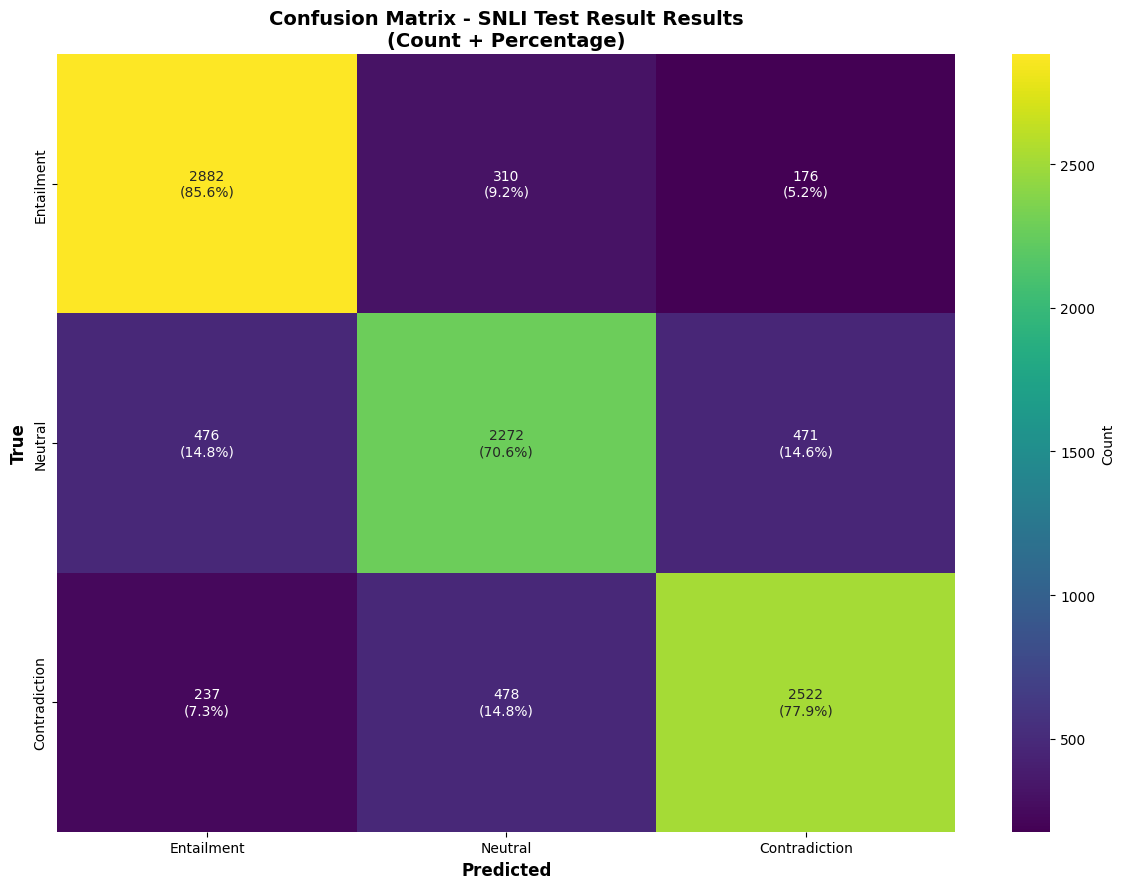

Confusion matrix saved to confusion_matrix_snli_test_result_20250713_192123.png

Classification Report - SNLI Test Result:
               precision    recall  f1-score   support

   Entailment       0.80      0.86      0.83      3368
      Neutral       0.74      0.71      0.72      3219
Contradiction       0.80      0.78      0.79      3237

     accuracy                           0.78      9824
    macro avg       0.78      0.78      0.78      9824
 weighted avg       0.78      0.78      0.78      9824


Per-Class Accuracy:
Entailment: 0.8557 accuracy (2882/3368)
Neutral: 0.7058 accuracy (2272/3219)
Contradiction: 0.7791 accuracy (2522/3237)

=== Summary of SNLI Test Evaluation ===
Loss: 0.5502
Accuracy: 0.7814
F1 (weighted): 0.7804
F1 (macro): 0.7796
F1 (micro): 0.7814

Per-Class Accuracy:
Entailment: 0.8557 (2882/3368)
Neutral: 0.7058 (2272/3219)
Contradiction: 0.7791 (2522/3237)


In [23]:
# final evaluation on test set

import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, f1_score, classification_report


def final_evaluation(model, dataloader, split_name, class_names=None, device=None):
    """
    Comprehensive evaluation function for final reporting on a dataset, excluding high-confidence error analysis.
    
    Args:
        model: PyTorch model in evaluation mode.
        dataloader: PyTorch DataLoader with input_ids, token_type_ids, label, attention_mask.
        split_name (str): Name of the dataset split (e.g., "Test", "Val Matched").
        class_names (list): List of class names (e.g., ["Entailment", "Neutral", "Contradiction"]). 
                           Defaults to None, using numeric labels if not provided.
        device: Torch device (e.g., torch.device("cuda")). If None, uses model's device.
    
    Returns:
        dict: Metrics including loss, accuracy, F1 scores, confusion matrix, and per-class accuracy.
    """
    if device is None:
        device = next(model.parameters()).device
    
    if class_names is None:
        class_names = [f"Class {i}" for i in range(3)]  # Default for 3-class NLI task
    
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0
    num_examples = 0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Evaluating {split_name}", leave=False):
            # Move batch to device
            input_ids = batch["input_ids"].to(device)
            segment_ids = batch["token_type_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device).bool()
            
            # Forward pass
            logits, loss = model(input_ids, segment_ids, labels, attention_mask=attention_mask)
            
            # Compute predictions
            preds = torch.argmax(logits, dim=-1)
            
            # Track predictions and labels
            batch_size = input_ids.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            total_loss += loss.item() * batch_size
            num_examples += batch_size
    
    # Convert to numpy arrays for sklearn
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    
    # Calculate basic metrics
    correct = np.sum(y_true == y_pred)
    accuracy = correct / len(y_true)
    avg_loss = total_loss / num_examples  # Weighted average by batch size
    
    # Calculate F1 scores
    f1_micro = f1_score(y_true, y_pred, average='micro')
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Per-class accuracy
    per_class_accuracy = {}
    for cls_idx, cls_name in enumerate(class_names):
        cls_indices = np.where(y_true == cls_idx)[0]
        cls_correct = np.sum(y_pred[cls_indices] == y_true[cls_indices])
        cls_acc = cls_correct / len(cls_indices) if len(cls_indices) > 0 else 0
        per_class_accuracy[cls_name] = {
            "accuracy": cls_acc,
            "correct": int(cls_correct),
            "total": len(cls_indices)
        }
    
    # Print metrics
    print(f"\n=== {split_name} Evaluation ===")
    print(f"Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f} | F1 (weighted): {f1_weighted:.4f}")
    
    # Enhanced confusion matrix visualization
    print(f"\n=== Confusion Matrix Visualization ===")
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    plt.figure(figsize=(12, 9))
    
    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create custom annotations with count + percentage
    annotations = []
    for i in range(cm.shape[0]):
        row = []
        for j in range(cm.shape[1]):
            row.append(f'{cm[i,j]}\n({cm_percent[i,j]:.1f}%)')
        annotations.append(row)
    
    sns.heatmap(cm, annot=annotations, fmt='', cmap='viridis', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted', fontsize=12, fontweight='bold')
    plt.ylabel('True', fontsize=12, fontweight='bold')
    plt.title(f'Confusion Matrix - {split_name} Results\n(Count + Percentage)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    plot_filename = f'confusion_matrix_{split_name.lower().replace(" ", "_")}_{timestamp}.png'
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Confusion matrix saved to {plot_filename}")
    
    # Print classification report
    report = classification_report(y_true, y_pred, target_names=class_names)
    print(f"\nClassification Report - {split_name}:\n{report}")
    
    # Print per-class accuracy
    print(f"\nPer-Class Accuracy:")
    for cls_name, stats in per_class_accuracy.items():
        print(f"{cls_name}: {stats['accuracy']:.4f} accuracy "
              f"({stats['correct']}/{stats['total']})")
    
    # Return comprehensive metrics
    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "f1_micro": f1_micro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm.tolist(),
        "per_class_accuracy": per_class_accuracy
    }


# Load the saved model weights
model = BERT(BERTConfig())  # Initialize model with the same config
model.load_state_dict(torch.load("best_model.pt"))  # Load the best weights
model = model.to(device)  # Move model to the appropriate device
model.eval()  # Set model to evaluation mode

# Define class names for NLI task
class_names = ["Entailment", "Neutral", "Contradiction"]

# Run final evaluation on tokenized_test_mnli_matched
metrics = final_evaluation(
    model=model,
    dataloader=test_snli_dataloader,
    split_name="SNLI Test Result",
    class_names=class_names,
    device=device
)

# Optionally, print a summary of key metrics
print("\n=== Summary of SNLI Test Evaluation ===")
print(f"Loss: {metrics['loss']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1 (weighted): {metrics['f1_weighted']:.4f}")
print(f"F1 (macro): {metrics['f1_macro']:.4f}")
print(f"F1 (micro): {metrics['f1_micro']:.4f}")
print("\nPer-Class Accuracy:")
for cls_name, stats in metrics['per_class_accuracy'].items():
    print(f"{cls_name}: {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")



best_model.pt
confusion_matrix_anli_r1_0-shot_test_result_20250713_163918.png
confusion_matrix_anli_r123_0-shot_test_result_20250713_163911.png
confusion_matrix_anli_r2_0-shot_test_result_20250713_163851.png
confusion_matrix_anli_r2_0-shot_test_result_20250713_164205.png
confusion_matrix_anli_r3_0-shot_test_result_20250713_163901.png
confusion_matrix_anli_r3_0-shot_test_result_20250713_164216.png
confusion_matrix_snli_test_result_20250713_163703.png
confusion_matrix_snli_test_result_20250713_164032.png
confusion_matrix_snli_test_result_20250713_164104.png
confusion_matrix_snli_test_result_20250713_192123.png
final_model.pt
training_history.png


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


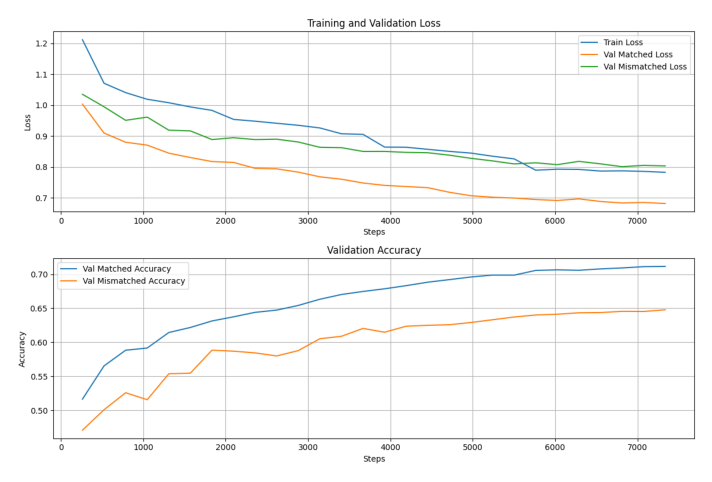


=== Confusion Matrix Visualization ===


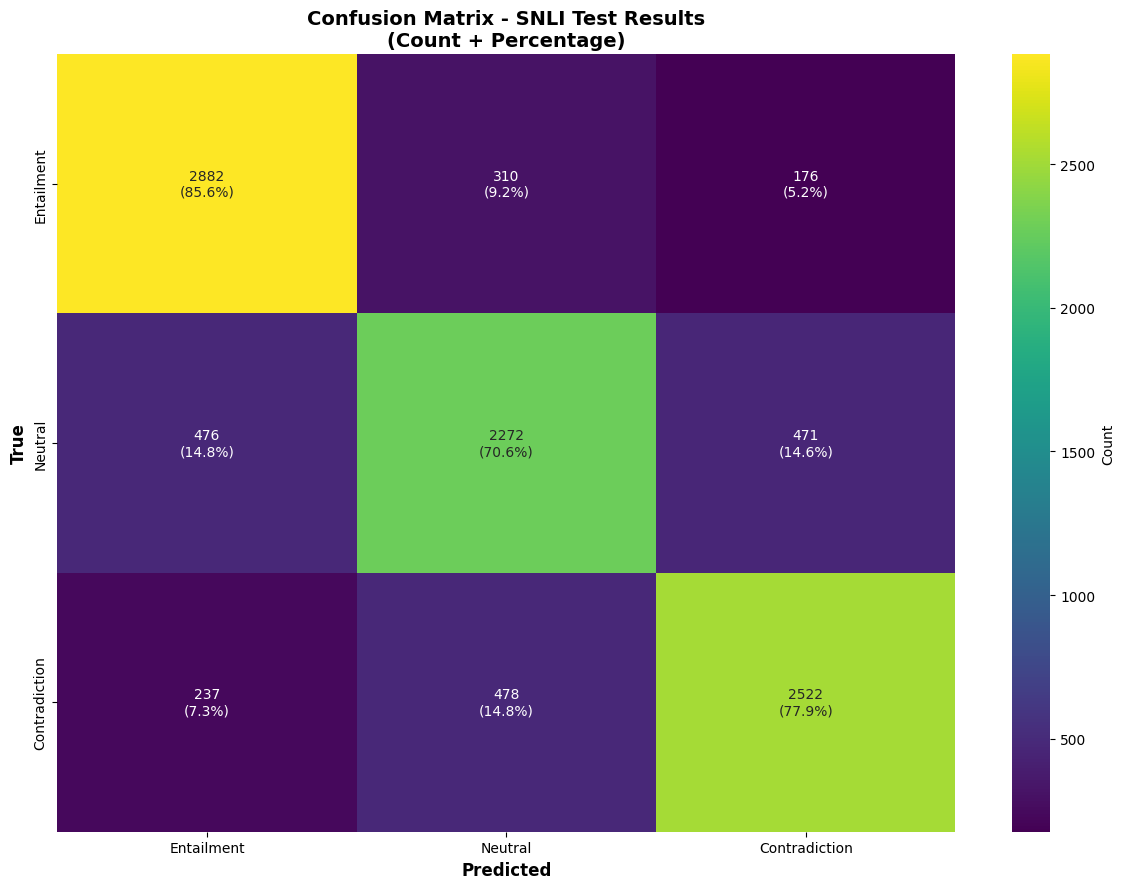

In [24]:
!ls
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('training_history.png')
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

# Display the confusion matrix heatmap again
print("\n=== Confusion Matrix Visualization ===")
plt.figure(figsize=(12, 9))
cm = np.array(metrics['confusion_matrix'])

# Calculate percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create custom annotations with count + percentage
annotations = []
for i in range(cm.shape[0]):
    row = []
    for j in range(cm.shape[1]):
        row.append(f'{cm[i,j]}\n({cm_percent[i,j]:.1f}%)')
    annotations.append(row)

sns.heatmap(cm, annot=annotations, fmt='', cmap='viridis', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('True', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - SNLI Test Results\n(Count + Percentage)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()  # This will display the plot

In [25]:
# anli dataset preprocessing
from datasets import load_dataset
from transformers import AutoTokenizer
from transformers import DataCollatorWithPadding

# Load the ANLI dataset
anli_dataset = load_dataset("anli")
# print(anli_dataset) #original structure


# Remove 'uid' and 'reason' columns from all ANLI splits
anli_dataset = {
    split: ds.remove_columns(["uid", "reason"]) 
    for split, ds in anli_dataset.items()
}

# Function to filter out invalid labels
def filter_valid(example):
    return example["label"] != -1

# Filter all SNLI splits
anli_dataset = {
    split: ds.filter(filter_valid)
    for split, ds in anli_dataset.items()
}

print(anli_dataset)

# Look at an example from each round
# print("R1 example:", anli_dataset["test_r1"][0])
# print("R2 example:", anli_dataset["test_r2"][0])
# print("R3 example:", anli_dataset["test_r3"][0])

#combine r1,r2,r3

test_dataset_anli_r123 = concatenate_datasets([
    anli_dataset["test_r1"], 
    anli_dataset["test_r2"],
    anli_dataset["test_r3"]
]).shuffle(seed=42)


# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")


def tokenize_function(example):
    return tokenizer(
        example["premise"],
        example["hypothesis"],
        padding=False,  # No padding during tokenization
        truncation=True,
        max_length=128
    )

# Tokenize each dataset separately
tokenized_anli_test_r1 = anli_dataset["test_r1"].map(tokenize_function, batched=True)
tokenized_anli_test_r2 = anli_dataset["test_r2"].map(tokenize_function, batched=True)
tokenized_anli_test_r3 = anli_dataset["test_r3"].map(tokenize_function, batched=True)

tokenized_anli_test_r123 = test_dataset_anli_r123.map(tokenize_function, batched=True)


tokenized_anli_test_r1 = tokenized_anli_test_r1.rename_column("label", "labels")
tokenized_anli_test_r2 = tokenized_anli_test_r2.rename_column("label", "labels")
tokenized_anli_test_r3 = tokenized_anli_test_r3.rename_column("label", "labels")
tokenized_anli_test_r123 = tokenized_anli_test_r123.rename_column("label", "labels")

tokenized_anli_test_r1.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_anli_test_r2.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_anli_test_r3.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])
tokenized_anli_test_r123.set_format("torch", columns=["input_ids", "token_type_ids", "attention_mask", "labels"])


batch_size = 512

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, max_length=128)

anli_test_r1_dataloader = DataLoader(
    tokenized_anli_test_r1,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)

anli_test_r2_dataloader = DataLoader(
    tokenized_anli_test_r2,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)

anli_test_r3_dataloader = DataLoader(
    tokenized_anli_test_r3,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)

anli_test_r123_dataloader = DataLoader(
    tokenized_anli_test_r123,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=data_collator
)



# Quick check
# print(f"Training batches: {len(anli_test_r1_dataloader)}") 
# print(f"Training batches: {len(anli_test_r2_dataloader)}") 
# print(f"Training batches: {len(anli_test_r3_dataloader)}") 
# print(f"Training batches: {len(anli_test_r123_dataloader)}") 



{'train_r1': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 16946
}), 'dev_r1': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 1000
}), 'test_r1': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 1000
}), 'train_r2': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 45460
}), 'dev_r2': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 1000
}), 'test_r2': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 1000
}), 'train_r3': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 100459
}), 'dev_r3': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 1200
}), 'test_r3': Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 1200
})}


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Evaluating ANLI R2 0-shot Test Result:   0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2714: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(



=== ANLI R2 0-shot Test Result Evaluation ===
Loss: 1.4815 | Accuracy: 0.2830 | F1 (weighted): 0.2789

=== Confusion Matrix Visualization ===


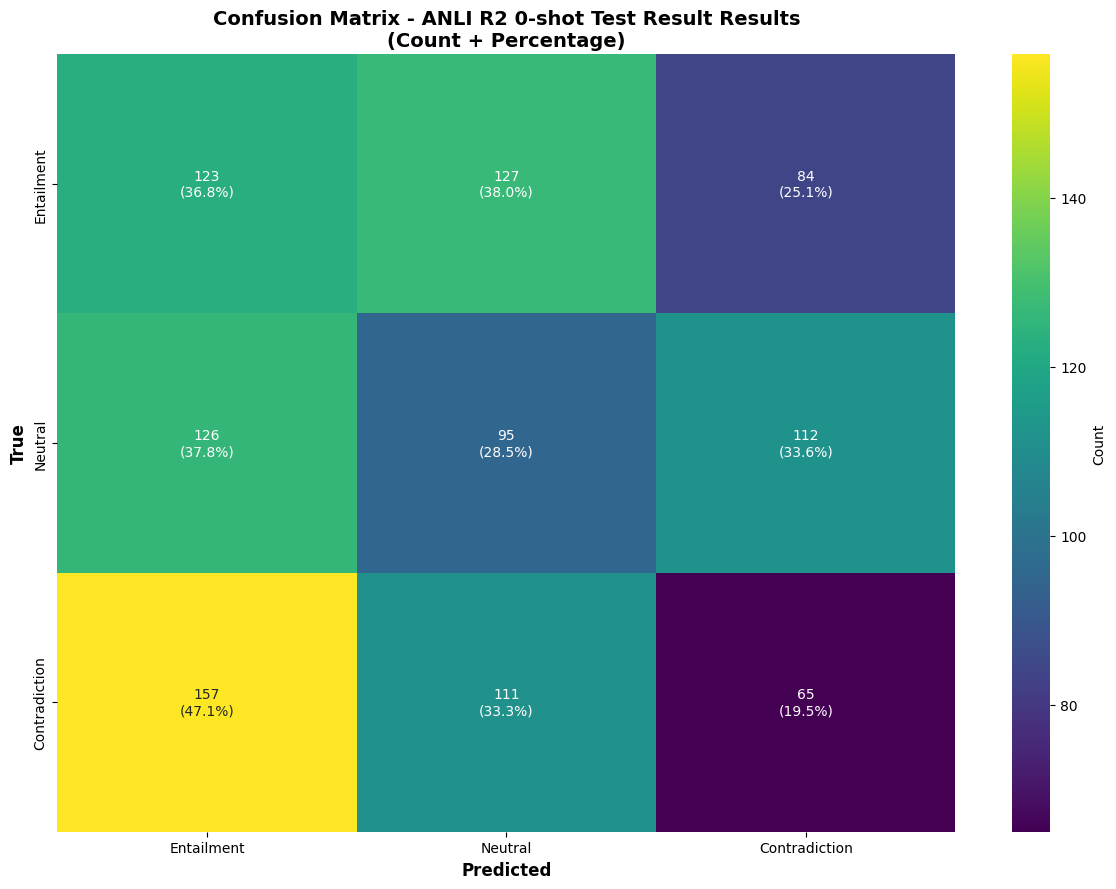

Confusion matrix saved to confusion_matrix_anli_r2_0-shot_test_result_20250713_192226.png

Classification Report - ANLI R2 0-shot Test Result:
               precision    recall  f1-score   support

   Entailment       0.30      0.37      0.33       334
      Neutral       0.29      0.29      0.29       333
Contradiction       0.25      0.20      0.22       333

     accuracy                           0.28      1000
    macro avg       0.28      0.28      0.28      1000
 weighted avg       0.28      0.28      0.28      1000


Per-Class Accuracy:
Entailment: 0.3683 accuracy (123/334)
Neutral: 0.2853 accuracy (95/333)
Contradiction: 0.1952 accuracy (65/333)

=== Summary of ANLI Test R2 Evaluation ===
Loss: 1.4815
Accuracy: 0.2830
F1 (weighted): 0.2789
F1 (macro): 0.2789
F1 (micro): 0.2830

Per-Class Accuracy:
Entailment: 0.3683 (123/334)
Neutral: 0.2853 (95/333)
Contradiction: 0.1952 (65/333)


In [26]:
# Load the saved model weights
model = BERT(BERTConfig())  # Initialize model with the same config
model.load_state_dict(torch.load("best_model.pt"))  # Load the best weights
model = model.to(device)  # Move model to the appropriate device
model.eval()  # Set model to evaluation mode

# Define class names for NLI task
class_names = ["Entailment", "Neutral", "Contradiction"]

# Run final evaluation on tokenized_test_mnli_matched
metrics = final_evaluation(
    model=model,
    dataloader=anli_test_r2_dataloader,
    split_name="ANLI R2 0-shot Test Result",
    class_names=class_names,
    device=device
)

# Optionally, print a summary of key metrics
print("\n=== Summary of ANLI Test R2 Evaluation ===")
print(f"Loss: {metrics['loss']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1 (weighted): {metrics['f1_weighted']:.4f}")
print(f"F1 (macro): {metrics['f1_macro']:.4f}")
print(f"F1 (micro): {metrics['f1_micro']:.4f}")
print("\nPer-Class Accuracy:")
for cls_name, stats in metrics['per_class_accuracy'].items():
    print(f"{cls_name}: {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")

Evaluating ANLI R3 0-shot Test Result:   0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2714: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(



=== ANLI R3 0-shot Test Result Evaluation ===
Loss: 1.4719 | Accuracy: 0.2967 | F1 (weighted): 0.2946

=== Confusion Matrix Visualization ===


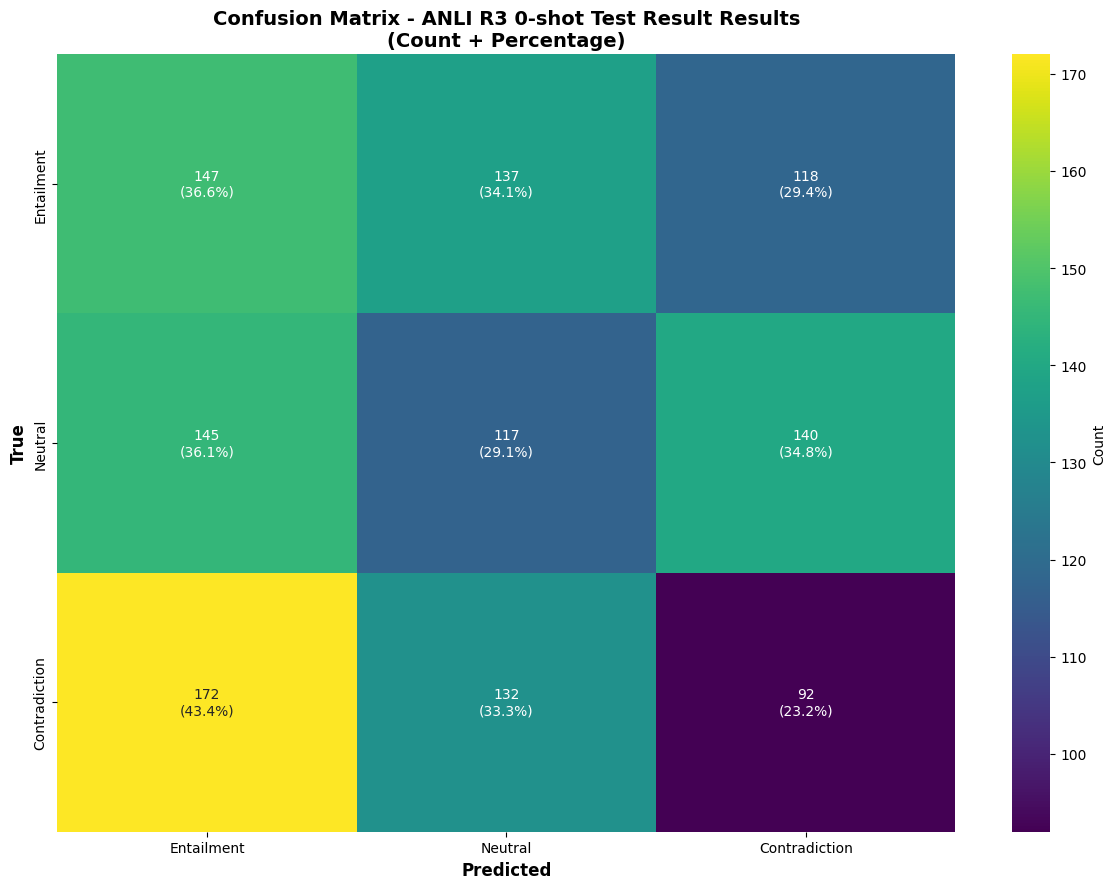

Confusion matrix saved to confusion_matrix_anli_r3_0-shot_test_result_20250713_192241.png

Classification Report - ANLI R3 0-shot Test Result:
               precision    recall  f1-score   support

   Entailment       0.32      0.37      0.34       402
      Neutral       0.30      0.29      0.30       402
Contradiction       0.26      0.23      0.25       396

     accuracy                           0.30      1200
    macro avg       0.29      0.30      0.29      1200
 weighted avg       0.29      0.30      0.29      1200


Per-Class Accuracy:
Entailment: 0.3657 accuracy (147/402)
Neutral: 0.2910 accuracy (117/402)
Contradiction: 0.2323 accuracy (92/396)

=== Summary of ANLI Test R3 Evaluation ===
Loss: 1.4719
Accuracy: 0.2967
F1 (weighted): 0.2946
F1 (macro): 0.2944
F1 (micro): 0.2967

Per-Class Accuracy:
Entailment: 0.3657 (147/402)
Neutral: 0.2910 (117/402)
Contradiction: 0.2323 (92/396)


In [27]:
# Run final evaluation on tokenized_test_mnli_matched
metrics = final_evaluation(
    model=model,
    dataloader=anli_test_r3_dataloader,
    split_name="ANLI R3 0-shot Test Result",
    class_names=class_names,
    device=device
)

# Optionally, print a summary of key metrics
print("\n=== Summary of ANLI Test R3 Evaluation ===")
print(f"Loss: {metrics['loss']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1 (weighted): {metrics['f1_weighted']:.4f}")
print(f"F1 (macro): {metrics['f1_macro']:.4f}")
print(f"F1 (micro): {metrics['f1_micro']:.4f}")
print("\nPer-Class Accuracy:")
for cls_name, stats in metrics['per_class_accuracy'].items():
    print(f"{cls_name}: {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")

Evaluating ANLI R123 0-shot Test Result:   0%|          | 0/7 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2714: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(



=== ANLI R123 0-shot Test Result Evaluation ===
Loss: 1.5099 | Accuracy: 0.2819 | F1 (weighted): 0.2782

=== Confusion Matrix Visualization ===


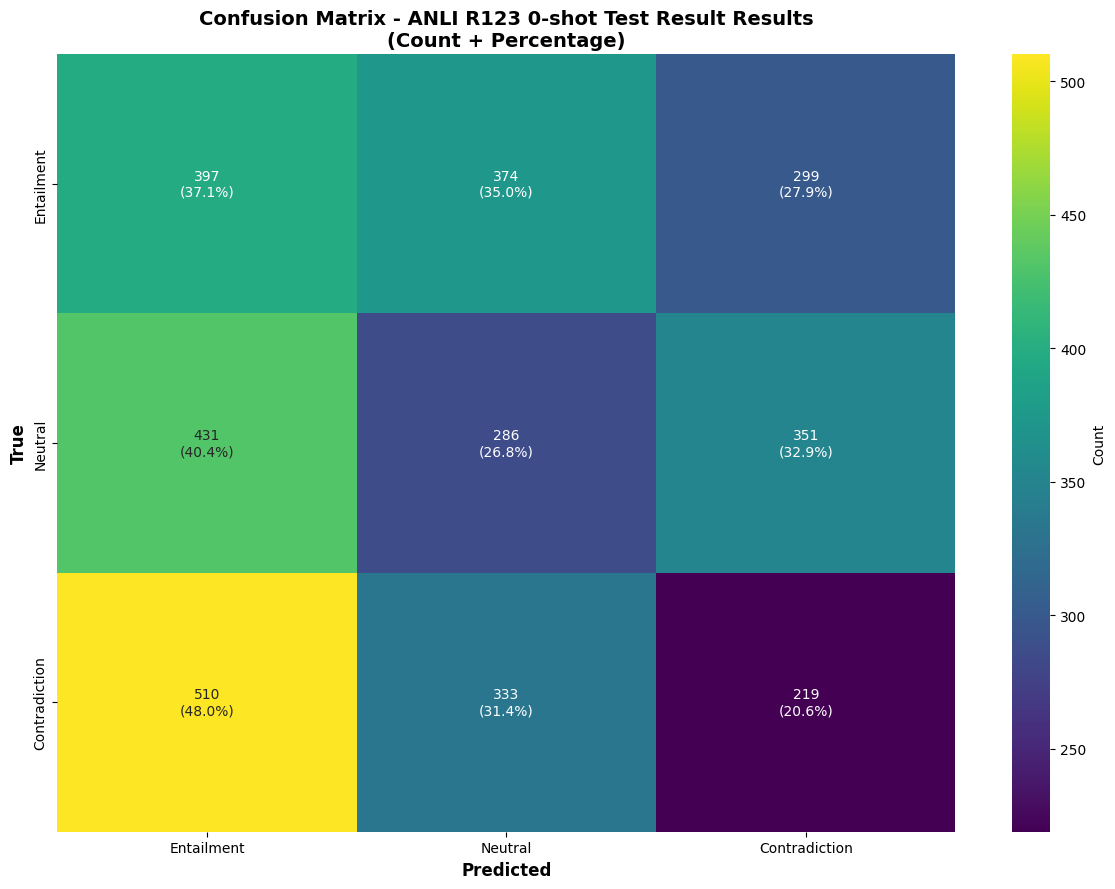

Confusion matrix saved to confusion_matrix_anli_r123_0-shot_test_result_20250713_192253.png

Classification Report - ANLI R123 0-shot Test Result:
               precision    recall  f1-score   support

   Entailment       0.30      0.37      0.33      1070
      Neutral       0.29      0.27      0.28      1068
Contradiction       0.25      0.21      0.23      1062

     accuracy                           0.28      3200
    macro avg       0.28      0.28      0.28      3200
 weighted avg       0.28      0.28      0.28      3200


Per-Class Accuracy:
Entailment: 0.3710 accuracy (397/1070)
Neutral: 0.2678 accuracy (286/1068)
Contradiction: 0.2062 accuracy (219/1062)

=== Summary of ANLI Test R123 Evaluation ===
Loss: 1.5099
Accuracy: 0.2819
F1 (weighted): 0.2782
F1 (macro): 0.2780
F1 (micro): 0.2819

Per-Class Accuracy:
Entailment: 0.3710 (397/1070)
Neutral: 0.2678 (286/1068)
Contradiction: 0.2062 (219/1062)


In [28]:
# Run final evaluation on tokenized_test_mnli_matched
metrics = final_evaluation(
    model=model,
    dataloader=anli_test_r123_dataloader,
    split_name="ANLI R123 0-shot Test Result",
    class_names=class_names,
    device=device
)

# Optionally, print a summary of key metrics
print("\n=== Summary of ANLI Test R123 Evaluation ===")
print(f"Loss: {metrics['loss']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1 (weighted): {metrics['f1_weighted']:.4f}")
print(f"F1 (macro): {metrics['f1_macro']:.4f}")
print(f"F1 (micro): {metrics['f1_micro']:.4f}")
print("\nPer-Class Accuracy:")
for cls_name, stats in metrics['per_class_accuracy'].items():
    print(f"{cls_name}: {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")


Evaluating ANLI R1 0-shot Test Result:   0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2714: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(



=== ANLI R1 0-shot Test Result Evaluation ===
Loss: 1.5876 | Accuracy: 0.2520 | F1 (weighted): 0.2465

=== Confusion Matrix Visualization ===


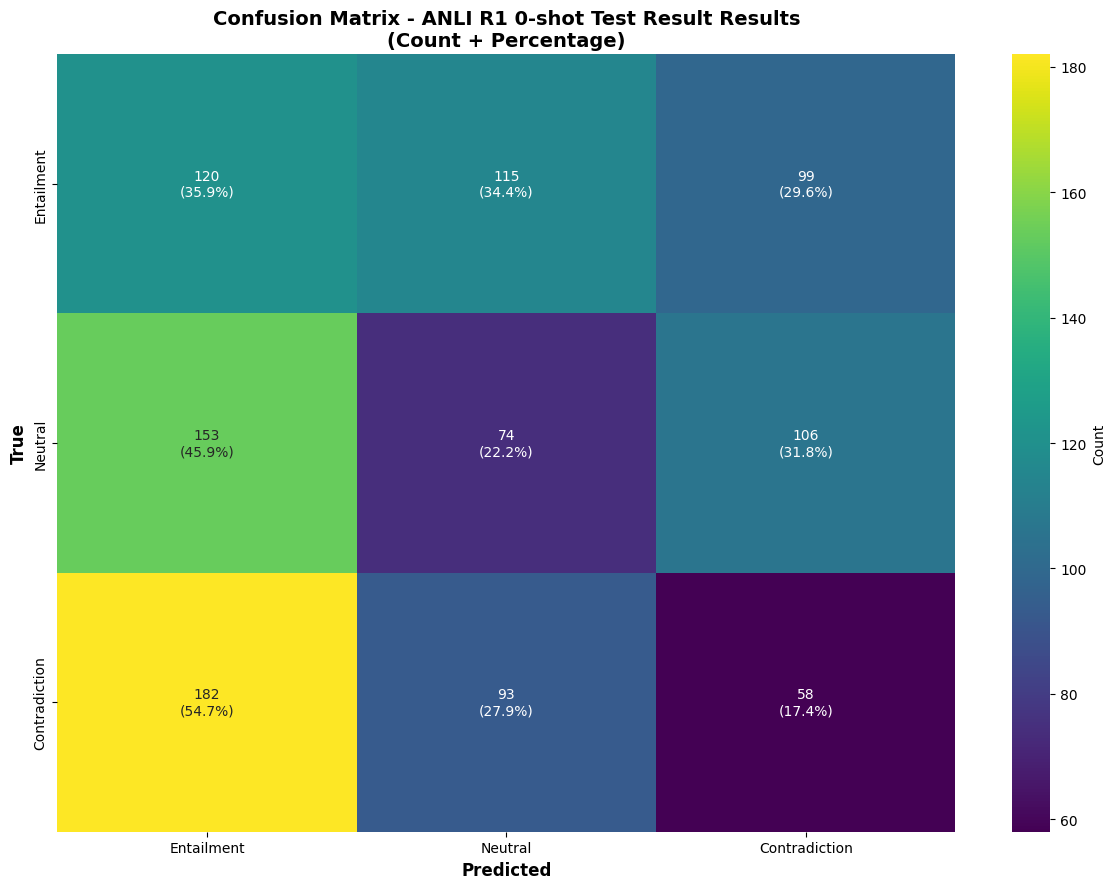

Confusion matrix saved to confusion_matrix_anli_r1_0-shot_test_result_20250713_192302.png

Classification Report - ANLI R1 0-shot Test Result:
               precision    recall  f1-score   support

   Entailment       0.26      0.36      0.30       334
      Neutral       0.26      0.22      0.24       333
Contradiction       0.22      0.17      0.19       333

     accuracy                           0.25      1000
    macro avg       0.25      0.25      0.25      1000
 weighted avg       0.25      0.25      0.25      1000


Per-Class Accuracy:
Entailment: 0.3593 accuracy (120/334)
Neutral: 0.2222 accuracy (74/333)
Contradiction: 0.1742 accuracy (58/333)

=== Summary of ANLI Test R123 Evaluation ===
Loss: 1.5876
Accuracy: 0.2520
F1 (weighted): 0.2465
F1 (macro): 0.2465
F1 (micro): 0.2520

Per-Class Accuracy:
Entailment: 0.3593 (120/334)
Neutral: 0.2222 (74/333)
Contradiction: 0.1742 (58/333)


In [29]:
# Run final evaluation on tokenized_test_mnli_matched
metrics = final_evaluation(
    model=model,
    dataloader=anli_test_r1_dataloader,
    split_name="ANLI R1 0-shot Test Result",
    class_names=class_names,
    device=device
)

# Optionally, print a summary of key metrics
print("\n=== Summary of ANLI Test R123 Evaluation ===")
print(f"Loss: {metrics['loss']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1 (weighted): {metrics['f1_weighted']:.4f}")
print(f"F1 (macro): {metrics['f1_macro']:.4f}")
print(f"F1 (micro): {metrics['f1_micro']:.4f}")
print("\nPer-Class Accuracy:")
for cls_name, stats in metrics['per_class_accuracy'].items():
    print(f"{cls_name}: {stats['accuracy']:.4f} ({stats['correct']}/{stats['total']})")


In [18]:
# clear cache memory

import torch
import gc

# Delete model, optimizer, and any large tensors
del model  # Replace with your model variable name
del optimizer  # Replace with your optimizer variable name
# Delete other large tensors if applicable, e.g., del train_loader

# Clear GPU memory cache
torch.cuda.empty_cache()

# Run garbage collection
#

gc.collect()

# Check memory usage again
print(f"Current GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"Current GPU memory reserved: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

Current GPU memory allocated: 0.02 GB
Current GPU memory reserved: 0.17 GB
